In [4]:
using Pkg

Pkg.activate("..") # From demos/ we go one level up to the project root
Pkg.instantiate()  # Optional, but recommended to ensure all dependencies are installed

using MiniOps
using Random
using LinearAlgebra
using Plots
using Random 
using SeisProcessing


  Activating project at `~/Dropbox/MiniOps`


In [2]:


# ---------------------------------------------------------
# Simple blending / adjoint-gather example
# ---------------------------------------------------------

Random.seed!(0)


nt = 501
ns = 5
dt = 0.004

# Relative source firing times in seconds.
# They do not need to be integer multiples of dt.
source_times = [0.000, 0.273, 0.521, 0.806, 1.047]

# A common-receiver gather: time × source.
D = randn(nt, ns)

B = blending_op(source_times, dt, nt)

# Blending: (t, source) -> blended time record
b = B * D

# Adjoint gathering: blended time record -> (t, source)
Da = B' * b

println("Input gather size      = ", size(D))
println("Blended record length = ", length(b))
println("Adjoint gather size    = ", size(Da))

# Dot-product test
x = randn(nt, ns)
y = randn(length(b))

lhs = dot(B * x, y)
rhs = dot(x, B' * y)
err = abs(lhs - rhs) / max(abs(lhs), abs(rhs), eps())

println("Adjoint relative error = ", err)


Input gather size      = (501, 5)
Blended record length = 763
Adjoint gather size    = (501, 5)
Adjoint relative error = 3.864503242467777e-16


(301, 101)


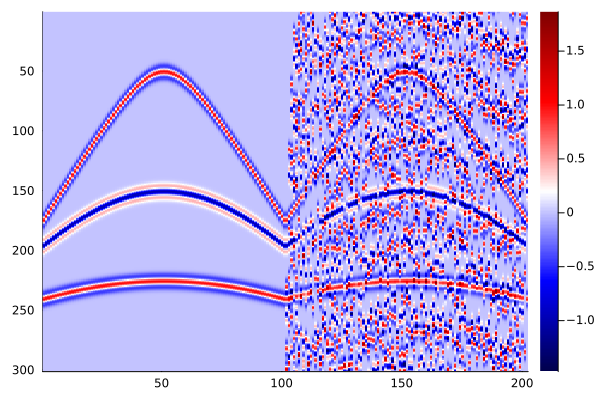

In [5]:
d=SeisHypEvents(); println(size(d))

nt,ns = size(d)
dt = 0.004

source_times = collect(0:1:ns-1)*.2+0.1rand(ns)
B = blending_op(source_times, dt, nt);
b = B*d
dp = B'*b;

heatmap(hcat(d,dp),colormap=:seismic,yflip=true)